In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

In [2]:
views_df = pd.read_csv("../output/5by5_custom_views_df.csv")

In [25]:
import ast

def parse_row(s):
    # Convert the string to an actual Python list
    items = ast.literal_eval(s)
    # Join everything into a single string
    return "".join(items)

In [29]:
views_df.view = (views_df.view).apply(parse_row)

In [30]:
# Basic frequency of exact views by label
view_counts = views_df.groupby(['view','center']).size().reset_index(name='count')
view_counts.sort_values('count', ascending=False).head(10)

,view,center,count
502,xxxx.rb.x.gg.,b,403392
476,xrb.r.ggxr..g,g,251764
306,gr..r.g.xr..x,g,197908
430,xb.x.ggxx..x.,g,197908
501,xxxx.rb.x.g.g,b,143079
432,xb.x.ggxx.gx.,g,142119
504,xxxx.rb.xbgg.,b,135911
500,xxxx.rb.x.g..,b,113725
467,xrb.r.g.xr..g,g,108752
437,xb.xbggxx..x.,g,100679


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- helpers: color map for characters ---
CHAR_PALETTE = {
    'r': '#d62728',   # red
    'g': '#2ca02c',   # green
    'b': '#1f77b4',   # blue
    '.': '#ffffff',   # white (empty)
    'x': '#aaaaaa',   # gray (boundary / outside)
    'd': '#ffdd55',   # EXI meta (inside) - yellow-ish
    'o': '#bbbbff',   # ANY meta - light blue/purple
    '?': '#f0f0f0',   # fallback
}

def char_to_color(ch):
    return CHAR_PALETTE.get(ch, CHAR_PALETTE['?'])


# ---------- visualize single 13-cell view (diamond) ----------
def visualize_view(view13, ax=None, title=None, show=True, annotate_indices=False, fontsize=12):
    """
    Visualize a single 13-element view in the diamond layout
    in ViewIndex order:
      [U2, UL, U1, UR, L2, L1, C, R1, R2, DL, D1, DR, D2]

    Args:
      view13: string or list/tuple length 13 of chars (e.g., '...xg.gxx..x.' or ['x','r','.',...])
      ax: optional matplotlib Axes to draw into. If None, a new figure+ax is created.
      title: optional title for the plot
      show: whether to plt.show()
      annotate_indices: if True, draw small gray index numbers below nodes
      fontsize: label font size
    Returns:
      ax: matplotlib Axes used
    """
    # accept string or list
    if isinstance(view13, str):
        view13 = list(view13)

    if len(view13) != 13:
        raise ValueError("view13 must be length 13")

    # Layout coordinates (hand-tuned for nice diamond)
    coords = {
        0: (2, 0),   # U2
        1: (1, 1),   # UL
        2: (2, 1),   # U1
        3: (3, 1),   # UR
        4: (0, 2),   # L2
        5: (1, 2),   # L1
        6: (2, 2),   # C
        7: (3, 2),   # R1
        8: (4, 2),   # R2
        9: (1, 3),   # DL
        10:(2, 3),   # D1
        11:(3, 3),   # DR
        12:(2, 4),   # D2
    }

    xs = np.array([coords[i][0] for i in range(13)], dtype=float)
    ys = np.array([coords[i][1] for i in range(13)], dtype=float)
    # center and scale
    xs = (xs - xs.mean()) * 1.2
    ys = (ys - ys.mean()) * 1.2

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        created_fig = True

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title or "2-hop diamond view")

    for idx in range(13):
        ch = view13[idx]
        x = xs[idx]
        y = -ys[idx]   # flip y to match top-down
        face = char_to_color(ch)
        circ = plt.Circle((x, y), 0.35, color=face, ec='k', lw=1)
        ax.add_patch(circ)
        ax.text(x, y, ch, ha='center', va='center',
                fontsize=fontsize, fontweight='bold')

        if annotate_indices:
            ax.text(x, y - 0.5, str(idx), ha='center', va='center',
                    fontsize=8, color='gray')

    # connect center to U1,L1,R1,D1 for clarity
    center_x, center_y = xs[6], -ys[6]
    for ni in (2, 5, 7, 10):
        ax.plot([center_x, xs[ni]],
                [center_y, -ys[ni]], color='k', lw=0.8)

    margin = 1.0
    ax.set_xlim(xs.min() - margin, xs.max() + margin)
    ax.set_ylim(-ys.max() - margin, -ys.min() + margin)

    if created_fig and show:
        plt.tight_layout()
        plt.show()

    return ax


In [32]:
from dataclasses import dataclass
import heapq
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt

# ---------- similarity matrix (as discussed) ----------
SYMBOLS_BASE = ['r', 'g', 'b', '.', 'x']
SYMBOLS_ALL  = ['r', 'g', 'b', '.', 'x', 'd', 'o']  # meta: d=EXI, o=ANY

S: Dict[Tuple[str, str], float] = {}

def set_sym(a, b, val):
    S[(a, b)] = val
    S[(b, a)] = val

# diagonal
for a in SYMBOLS_ALL:
    set_sym(a, a, 1.0)

robots = ['r', 'g', 'b']

# robot vs robot (different colors)
for a in robots:
    for b in robots:
        if a != b:
            set_sym(a, b, 0.7)

# robot vs empty
for a in robots:
    set_sym(a, '.', 0.3)

# empty vs boundary
set_sym('.', 'x', 0.1)

# robot vs boundary
for a in robots:
    set_sym(a, 'x', 0.0)

# meta 'd' (EXI) vs base
for a in robots:
    set_sym('d', a, 0.7)
set_sym('d', '.', 0.3)
set_sym('d', 'x', 0.0)

# meta 'o' (ANY) vs base
for a in robots:
    set_sym('o', a, 0.2)
set_sym('o', '.', 0.2)
set_sym('o', 'x', 0.5)

# d vs o
set_sym('d', 'o', 0.3)

# ---------- positional weights ----------
VIEW_LEN = 13
CENTER_IDX = 6
ONEHOP_IDXS = {2, 5, 7, 10}  # U1, L1, R1, D1

WEIGHTS = []
for i in range(VIEW_LEN):
    if i == CENTER_IDX:
        WEIGHTS.append(10)
    elif i in ONEHOP_IDXS:
        WEIGHTS.append(5)
    else:
        WEIGHTS.append(1)


def pattern_distance(view1: str, view2: str) -> float:
    """Weighted distance = sum_i w_i * (1 - S[a_i, b_i])."""
    assert len(view1) == len(view2) == VIEW_LEN
    dist = 0.0
    for i, (a, b) in enumerate(zip(view1, view2)):
        dist += WEIGHTS[i] * (1.0 - S[(a, b)])
    return dist


def merge_symbol(a: str, b: str) -> str:
    """
    Merge two symbols at one position, using EXI='d' and ANY='o'.
    """
    if a == b:
        return a
    if a == 'o' or b == 'o':
        return 'o'
    if a == 'x' and b != 'x':
        return 'o'
    if b == 'x' and a != 'x':
        return 'o'
    # both inside-ish {r,g,b,.,d}, different
    return 'd'


def merge_views(view1: str, view2: str) -> str:
    assert len(view1) == len(view2) == VIEW_LEN
    return ''.join(merge_symbol(a, b) for a, b in zip(view1, view2))


# ---------- tree node ----------
@dataclass
class PatternNode:
    id: int
    pattern: str     # 13-char with possible d/o
    count: int       # total support (sum of leaves)
    left: Optional[int]   # child ids (None for leaf)
    right: Optional[int]
    info_loss: float # pattern_distance(left.pattern, right.pattern) or 0 for leaf
    merge_cost: float # info_loss * count (global cost of this generalization)


def build_pattern_tree(view_counts_df,
                       center_value: str,
                       max_patterns: Optional[int] = None,
                       max_merges: Optional[int] = None):
    """
    Build a bottom-up merge tree for a single center type ('g' or 'b').

    view_counts_df: DataFrame with ['view','center','count'].
    center_value: 'g' or 'b'.
    max_patterns: only use top-N most frequent patterns (for speed).
    max_merges: stop after this many merges (else full merge).
    """
    import pandas as pd

    df = view_counts_df[view_counts_df['center'] == center_value].copy()
    df = df.sort_values('count', ascending=False)
    if max_patterns is not None:
        df = df.head(max_patterns)

    nodes: Dict[int, PatternNode] = {}
    active_ids = set()
    next_id = 0

    # Initialize leaves
    for _, row in df.iterrows():
        v = row['view']
        c = int(row['count'])
        node = PatternNode(
            id=next_id,
            pattern=v,
            count=c,
            left=None,
            right=None,
            info_loss=0.0,
            merge_cost=0.0
        )
        nodes[next_id] = node
        active_ids.add(next_id)
        next_id += 1

    if len(active_ids) <= 1:
        return nodes, active_ids

    # Initial pairwise merge candidates
    heap: List[Tuple[float, int, int]] = []
    active_list = list(active_ids)
    n = len(active_list)
    for i_idx in range(n):
        i = active_list[i_idx]
        for j_idx in range(i_idx + 1, n):
            j = active_list[j_idx]
            vi = nodes[i].pattern
            vj = nodes[j].pattern
            dist_ij = pattern_distance(vi, vj)
            merge_cost = dist_ij * (nodes[i].count + nodes[j].count)
            heapq.heappush(heap, (merge_cost, i, j))

    merges_done = 0

    # Greedy bottom-up merging
    while len(active_ids) > 1:
        if max_merges is not None and merges_done >= max_merges:
            break
        if not heap:
            break

        merge_cost, i, j = heapq.heappop(heap)
        if i not in active_ids or j not in active_ids:
            continue

        node_i = nodes[i]
        node_j = nodes[j]
        info_loss = pattern_distance(node_i.pattern, node_j.pattern)
        new_pattern = merge_views(node_i.pattern, node_j.pattern)
        new_count = node_i.count + node_j.count
        new_merge_cost = info_loss * new_count

        new_node = PatternNode(
            id=next_id,
            pattern=new_pattern,
            count=new_count,
            left=i,
            right=j,
            info_loss=info_loss,
            merge_cost=new_merge_cost
        )
        nodes[next_id] = new_node

        active_ids.remove(i)
        active_ids.remove(j)
        active_ids.add(next_id)

        # update heap with distances from new node
        for k in list(active_ids):
            if k == next_id:
                continue
            vk = nodes[k].pattern
            dist_nk = pattern_distance(new_pattern, vk)
            merge_cost_nk = dist_nk * (new_count + nodes[k].count)
            heapq.heappush(heap, (merge_cost_nk, next_id, k))

        next_id += 1
        merges_done += 1

    return nodes, active_ids

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle

def draw_view_in_box(ax, view13, x_center, y_center, box_width, box_height,
                     fontsize=10, annotate_indices=False):
    """
    Draw a large diamond inside a box. Much larger than the previous version.
    view13 should be a string or list of length 13.
    """
    if isinstance(view13, str):
        view13 = list(view13)

    if len(view13) != 13:
        raise ValueError("view13 must be length 13")

    # Diamond layout
    coords = {
        0: (2, 0), 1: (1, 1), 2: (2, 1), 3: (3, 1),
        4: (0, 2), 5: (1, 2), 6: (2, 2), 7: (3, 2), 8: (4, 2),
        9: (1, 3), 10: (2, 3), 11: (3, 3), 12: (2, 4)
    }

    # 👇 make them float arrays directly
    xs = np.array([coords[i][0] for i in range(13)], dtype=float)
    ys = np.array([coords[i][1] for i in range(13)], dtype=float)

    # Center coords
    xs -= xs.mean()
    ys -= ys.mean()

    # ---- larger usable area inside box ----
    margin_x = box_width * 0.10   # 10% margin horizontally
    margin_y = box_height * 0.18  # some space for header text

    usable_w = box_width  - 2 * margin_x
    usable_h = box_height - 2 * margin_y

    dx = xs.max() - xs.min()
    dy = ys.max() - ys.min()

    # Avoid division by zero (shouldn't happen, but be safe)
    scale_x = usable_w / dx if dx > 0 else 1.0
    scale_y = usable_h / dy if dy > 0 else 1.0
    scale = min(scale_x, scale_y)

    xs_scaled = xs * scale + x_center
    ys_scaled = -ys * scale + y_center   # flip y for top-down look

    # Larger node radius
    node_radius = min(box_width, box_height) * 0.12

    for idx in range(13):
        ch = view13[idx]
        x = xs_scaled[idx]
        y = ys_scaled[idx]

        circ = plt.Circle(
            (x, y),
            node_radius,
            facecolor=char_to_color(ch),
            edgecolor='k',
            lw=0.8
        )
        ax.add_patch(circ)

        ax.text(x, y, ch,
                ha='center', va='center',
                fontsize=fontsize, fontweight='bold')

        if annotate_indices:
            ax.text(x,
                    y - node_radius * 1.5,
                    str(idx),
                    ha='center', va='center',
                    fontsize=7,
                    color='gray')

def _assign_positions_wide(nodes, root_id, max_depth=None,
                           x_spacing=4.0, y_spacing=4.0):
    """
    Assign (x,y) positions to nodes with generous spacing so boxes don't overlap.
    x_spacing, y_spacing control horizontal/vertical distance between neighbors.
    """
    pos = {}
    current_x = 0.0

    def dfs(nid, depth):
        nonlocal current_x
        node = nodes[nid]
        if max_depth is not None and depth > max_depth:
            return

        # in-order: left, self, right
        if node.left is not None:
            dfs(node.left, depth + 1)

        x = current_x * x_spacing
        y = -float(depth) * y_spacing
        pos[nid] = (x, y)
        current_x += 1.0

        if node.right is not None:
            dfs(node.right, depth + 1)

    dfs(root_id, 0)

    # center the tree horizontally around 0
    xs = np.array([p[0] for p in pos.values()])
    if len(xs) > 0:
        shift = (xs.max() + xs.min()) / 2.0
        for nid in pos:
            x, y = pos[nid]
            pos[nid] = (x - shift, y)

    return pos

from matplotlib.patches import Rectangle

def plot_pattern_tree_with_views(nodes,
                                 root_id,
                                 max_depth=3,
                                 box_width=3.0,
                                 box_height=3.0,
                                 x_spacing=4.0,
                                 y_spacing=4.0,
                                 annotate_indices=False):
    """
    Draw a traditional top-down tree:
      - nodes as big boxes (no overlap)
      - each box contains:
          * header: id, depth, count, info_loss, merge_cost
          * diamond view inside
      - edges from parent to children
    """
    # Compute positions with wide spacing
    pos = _assign_positions_wide(nodes, root_id,
                                 max_depth=max_depth,
                                 x_spacing=x_spacing,
                                 y_spacing=y_spacing)
    if not pos:
        return

    # Collect subtree nodes (respecting max_depth)
    def collect_subtree(root, depth=0):
        out = []
        stack = [(root, 0)]
        while stack:
            nid, d = stack.pop()
            if max_depth is not None and d > max_depth:
                continue
            out.append((nid, d))
            node = nodes[nid]
            if node.left is not None:
                stack.append((node.left, d+1))
            if node.right is not None:
                stack.append((node.right, d+1))
        return out

    id_depth_pairs = collect_subtree(root_id)

    # Figure size: scale with width & depth of tree
    xs = [pos[nid][0] for nid, _ in id_depth_pairs]
    ys = [pos[nid][1] for nid, _ in id_depth_pairs]
    width_units = (max(xs) - min(xs)) + 3 * x_spacing
    height_units = (max(ys) - min(ys)) + 4 * y_spacing

    # 0.8 factor: tune if you want bigger/smaller
    fig_w = width_units * 0.8
    fig_h = abs(height_units) * 0.8

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_aspect('equal')
    ax.axis('off')

    # ---- Draw edges ----
    for nid, d in id_depth_pairs:
        node = nodes[nid]
        x0, y0 = pos[nid]
        for child_id in (node.left, node.right):
            if child_id is None or child_id not in pos:
                continue
            x1, y1 = pos[child_id]
            ax.plot([x0, x1],
                    [y0 - box_height/2, y1 + box_height/2],
                    color='k', lw=0.8)

    # ---- Draw nodes: boxes + header + diamond ----
    for nid, d in id_depth_pairs:
        node = nodes[nid]
        x, y = pos[nid]

        # box rectangle
        bx = x - box_width/2
        by = y - box_height/2
        rect = Rectangle((bx, by),
                         box_width,
                         box_height,
                         linewidth=1.2,
                         edgecolor='k',
                         facecolor='#f8f8ff')
        ax.add_patch(rect)

        # header text at top of box
        header_y = by + box_height - 0.2
        text_lines = [
            f"id={node.id}, depth={d}",
            f"count={node.count}",
            f"loss={node.info_loss:.1f}, cost={node.merge_cost:.1f}"
        ]
        ax.text(x, header_y, "\n".join(text_lines),
                ha='center', va='top', fontsize=8)

        # diamond view in the middle of the box
        cx = x
        cy = by + box_height * 0.45  # below header
        draw_view_in_box(
                            ax,
                            node.pattern,
                            cx, cy,
                            box_width*0.95,
                            box_height*0.80,   # give big space to diamond
                            fontsize=10,
                            annotate_indices=annotate_indices
                        )

    # set limits with a bit of margin
    ax.set_xlim(min(xs) - x_spacing, max(xs) + x_spacing)
    ax.set_ylim(min(ys) - 2*y_spacing, max(ys) + 2*y_spacing)

    plt.tight_layout()
    plt.show()



In [33]:
#atleast 1% of the total simulations have this view
patterns = view_counts[view_counts['count'] > 1000000*0.01]

In [34]:
patterns.reset_index(inplace=True, drop='index')

In [35]:
patterns.sort_values('count', inplace=True, ascending=False)

/tmp/ipykernel_9122/3893824760.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patterns.sort_values('count', inplace=True, ascending=False)


In [36]:
nodes_b, roots_b = build_pattern_tree(patterns,
                                      center_value='b')





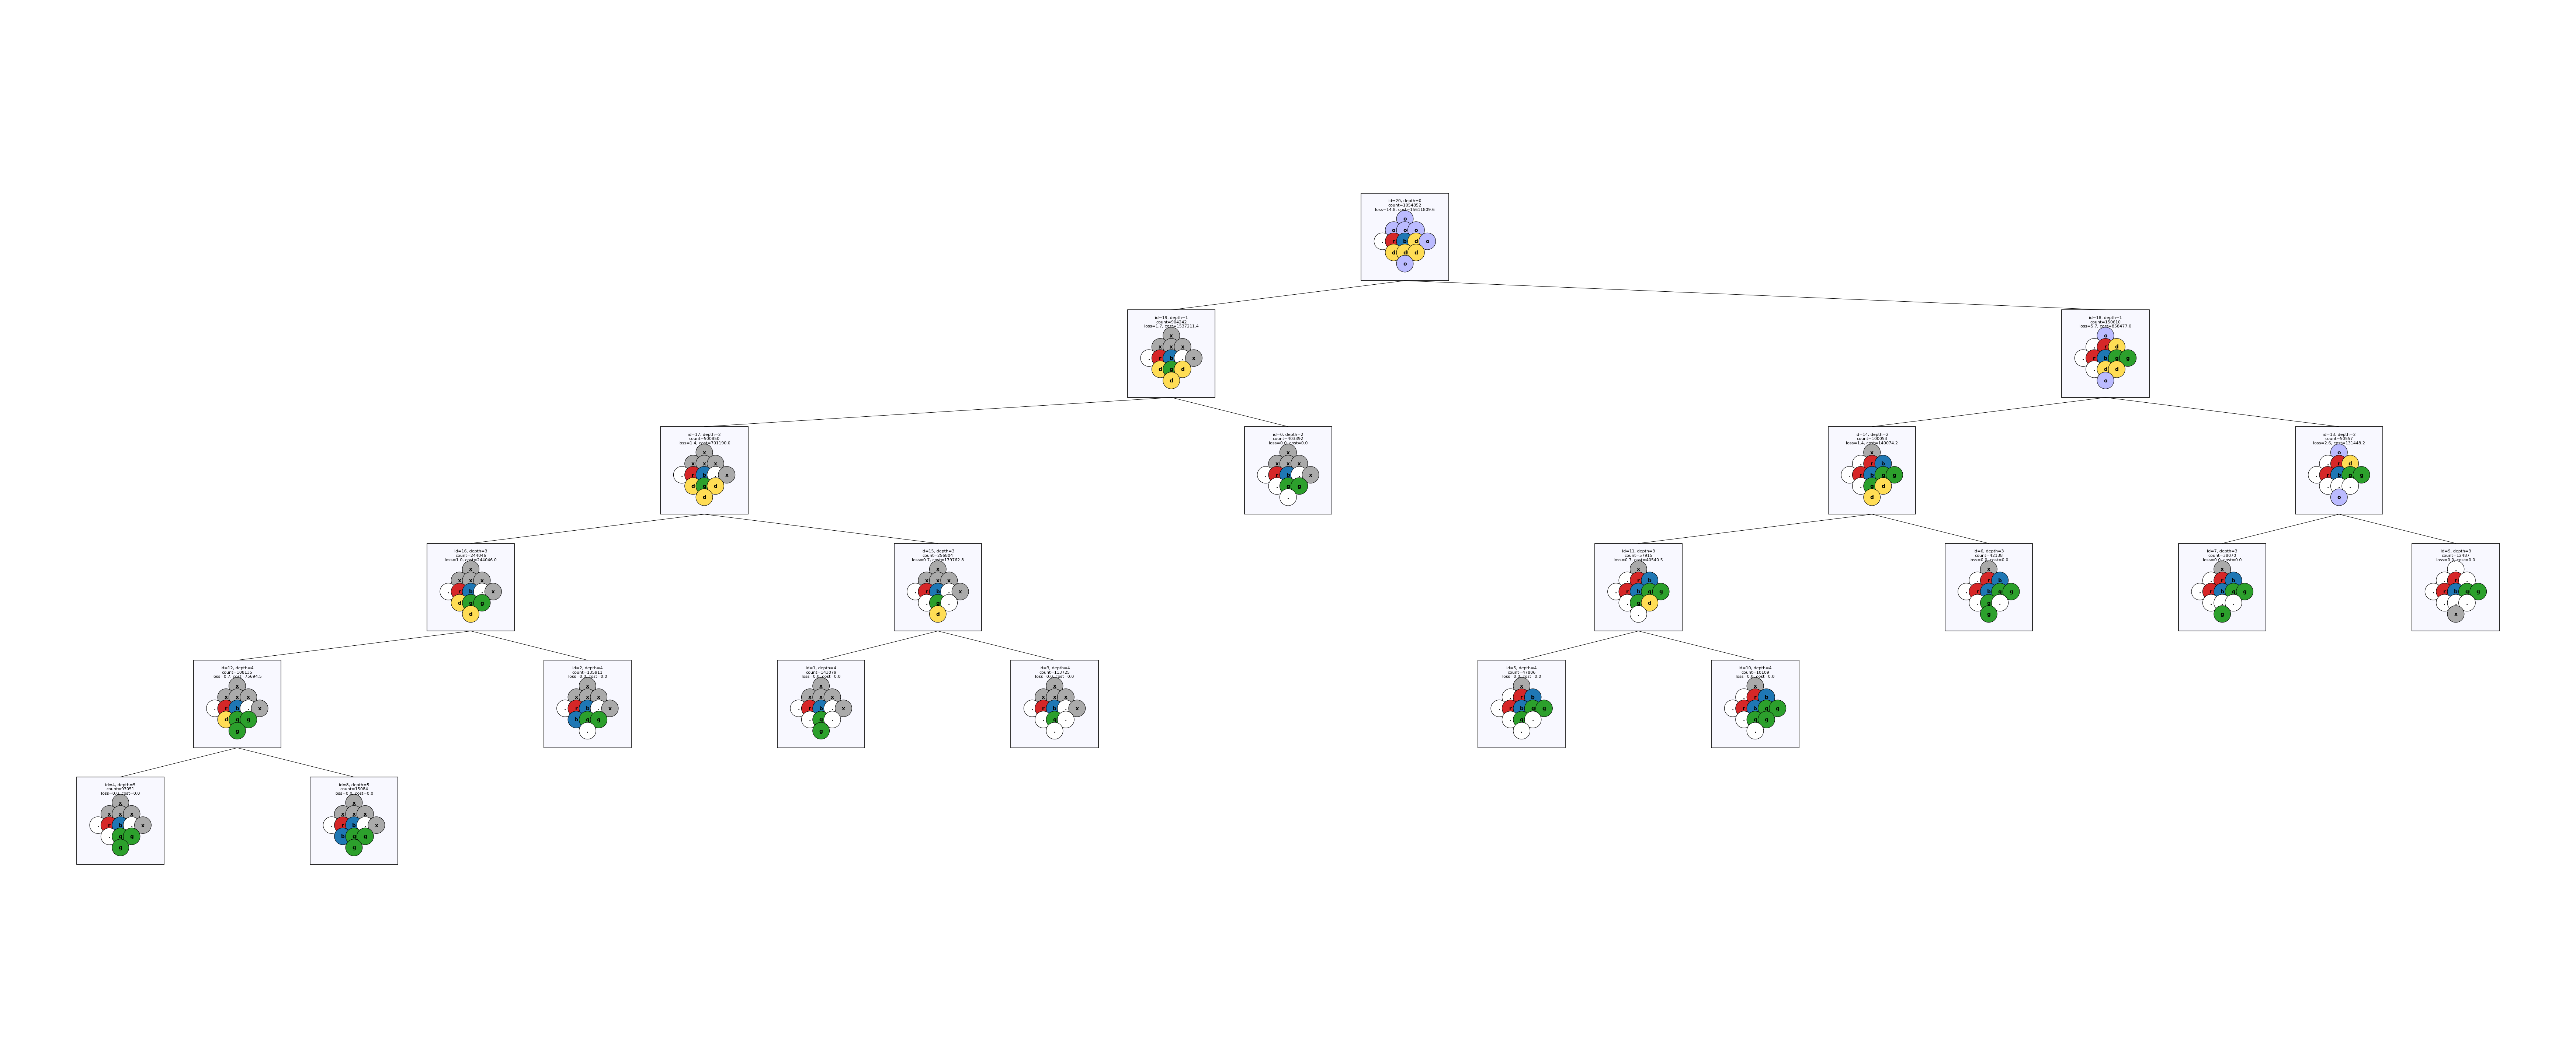

In [37]:
root_id = next(iter(roots_b))

# Big, non-overlapping tree
plot_pattern_tree_with_views(
    nodes_b,
    root_id=root_id,
    max_depth=20,          # go as deep as you like
    box_width=3.0,
    box_height=3.0,
    x_spacing=4.0,
    y_spacing=4.0,
    annotate_indices=False
)

In [38]:
nodes_g_full, roots_g_full = build_pattern_tree(patterns,
                                      center_value='g')
root_id = next(iter(roots_g_full))

# Big, non-overlapping tree
plot_pattern_tree_with_views(
    nodes_g_full,
    root_id=root_id,
    max_depth=20,          # go as deep as you like
    box_width=3.0,
    box_height=3.0,
    x_spacing=4.0,
    y_spacing=4.0,
    annotate_indices=False
)